<div align="center">

<br><br>

# **BOUNDARY VALUE PROBLEM (BVP)**  
## *Metode Beda Hingga*

<!-- Ganti "logo_unhas.png" dengan nama file logo kamu -->
<img src="Logo-Resmi-Unhas-1.png" width="200">

<br><br>

<h3><strong>Disusun oleh:</strong></h3>

<div style="width:50%">

  <div style="display:flex; justify-content:space-between;">
    <span><strong>Muhammad Irfan</strong></span><span><strong>H061241002</strong></span>
  </div>
  <div style="display:flex; justify-content:space-between;">
    <span><strong>Indah</strong></span><span><strong>H061241004</strong></span>
  </div>
  <div style="display:flex; justify-content:space-between;">
    <span><strong>Syamsuddin</strong></span><span><strong>H061241006</strong></span>
  </div>
  <div style="display:flex; justify-content:space-between;">
    <span><strong>Ananta Saputra</strong></span><span><strong>H061241010</strong></span>
  </div>
  <div style="display:flex; justify-content:space-between;">
    <span><strong>Nirwana</strong></span><span><strong>H061241011</strong></span>
  </div>
  <div style="display:flex; justify-content:space-between;">
    <span><strong>Mila Ayu Lestari</strong></span><span><strong>H061241013</strong></span>
  </div>
  <div style="display:flex; justify-content:space-between;">
    <span><strong>Aschani Trianita Theopilus</strong></span><span><strong>H061241019</strong></span>
  </div>
  <div style="display:flex; justify-content:space-between;">
    <span><strong>Ramlah</strong></span><span><strong>H061241025</strong></span>
  </div>
  <div style="display:flex; justify-content:space-between;">
    <span><strong>Serilia Abung</strong></span><span><strong>H061241034</strong></span>
  </div>
  <div style="display:flex; justify-content:space-between;">
    <span><strong>Brigita Kenes Wulandari S.</strong></span><span><strong>H061241037</strong></span>
  </div>
  <div style="display:flex; justify-content:space-between;">
    <span><strong>Nasrullah</strong></span><span><strong>H061241040</strong></span>
  </div>
  <div style="display:flex; justify-content:space-between;">
    <span><strong>Budia Awaliyah Hasir</strong></span><span><strong>H061241043</strong></span>
  </div>

</div>
<br>

### **Program Studi Geofisika**
### **Fakultas Matematika dan Ilmu Pengetahuan Alam**
### **Universitas Hasanuddin**

<br>

### **Tahun 2026**

</div>

In [2]:
from __future__ import print_function

%matplotlib inline

import numpy
import matplotlib.pyplot as plt

## Masalah Nilai Batas: Diskritisasi
### Masalah Model

Masalah nilai batas paling sederhana (BVP) yang akan kita hadapi adalah persamaan Poisson versi satu dimensi
 $$
    u''(x) = f(x).
$$

Biasanya persamaan ini diselesaikan pada interval berhingga dengan kondisi batas Dirichlet atau Neumann. Karena pada persamaan tersebut terdapat dua turunan, maka diperlukan dua kondisi batas agar persamaan diferensial dapat memiliki solusi yang unik. Untuk memulai, kita pertimbangkan masalah dasar berikut

$$
\begin{aligned}
u''(x) &= f(x), \quad \Omega = [a, b] \\
u(a) &= \alpha \\
u(b) &= \beta
\end{aligned}
$$

BVP seperti ini sering muncul dari bentuk keadaan tunak (steady state) suatu PDE yang bergantung pada waktu. Sebagai contoh, perhatikan persamaan kalor berikut

$$
u_t(x,t) = \kappa u_{xx}(x,t) + \Psi(x,t), \quad \Omega = [0, T] \times [a, b]
$$

dengan kondisi

$$
u(x,0) = u^0(x), \quad u(a,t) = \alpha(t), \quad u(b,t) = \beta(t)
$$

Jika kita mencari solusi keadaan tunak, maka perubahan terhadap waktu tidak ada sehingga

$$
u_t = 0
$$

Akibatnya persamaan menjadi

$$
u''(x) = - \frac{\Psi}{\kappa}
$$

yang merupakan bentuk persamaan Poisson seperti yang telah dibahas sebelumnya.

Dalam dimensi spasial yang lebih tinggi, turunan kedua berubah menjadi operator **Laplacian**. Notasinya dapat berbeda, tetapi semuanya memiliki arti yang sama, yaitu

$$
\begin{aligned}
\nabla^2 u(\vec{x}) &= f(\vec{x}) \\
\Delta u(\vec{x}) &= f(\vec{x}) \\
\sum_{i=1}^{N} u_{x_i x_i} &= f(\vec{x})
\end{aligned}
$$

### Diskritisasi Satu Dimensi

Sebagai pendekatan awal untuk menyelesaikan persamaan Poisson satu dimensi, domain dibagi menjadi beberapa titik berjumlah `m` yang disebut *mesh* atau *grid*. Tujuannya adalah memperkirakan fungsi yang tidak diketahui $u(x)$ pada titik-titik mesh $x_i$.

Hubungan antara jumlah titik `m` dan jarak antar titik diberikan oleh

$$
\Delta x = \frac{1}{m + 1}.
$$

Titik mesh $x_i$ dapat dituliskan sebagai

$$
x_i = a + i\Delta x.
$$

Kita juga dapat membiarkan $\Delta x$ bervariasi, dan sebagian besar rumus di atas hanya mengalami sedikit perubahan. Namun, pembahasan tersebut akan diserahkan sebagai latihan. 

Secara notasi, kita menggunakan

$$
U_i \approx u(x_i)
$$

yang berarti $U_i$ adalah solusi pendekatan pada titik grid, sedangkan huruf kecil $u$ menyatakan solusi sebenarnya.

Untuk menyederhanakan pembahasan, kita pertimbangkan ODE berikut

$$
u''(x) = f(x), \quad \Omega = [0,1]
$$

dengan kondisi batas

$$
u(0) = \alpha, \quad u(1) = \beta
$$

Dengan menggunakan pendekatan beda hingga terpusat orde dua untuk turunan kedua, diperoleh persamaan

$$
D^2 U_i = \frac{1}{\Delta x^2}(U_{i+1} - 2U_i + U_{i-1})
$$

Sehingga pada setiap titik grid diperoleh bentuk aljabar

$$
\frac{1}{\Delta x^2}(U_{i+1} - 2U_i + U_{i-1}) = f(x_i), \quad i = 1,2,3,\ldots,m.
$$

Perhatikan bahwa persamaan aljabar ini saling berkaitan karena setiap $U_i$ bergantung pada titik tetangganya. Oleh karena itu, persamaan tersebut dapat dituliskan sebagai sistem persamaan linear

$$
A U = F
$$

Tulis sistem persamaannya

$$
\frac{1}{\Delta x^2}(U_{i+1} - 2U_i + U_{i-1}) = f(x_i), \quad i = 1,2,3,\ldots,m
$$

Perhatikan kondisi batasnya.

$$
    \frac{1}{\Delta x^2} \begin{bmatrix}
    -2 &  1 &    &    &    \\
     1 & -2 &  1 &    &    \\
       &  1 & -2 &  1 &    \\
       &    &  1 & -2 &  1 \\
       &    &    &  1 & -2 \\
    \end{bmatrix} \begin{bmatrix}
        U_1 \\ U_2 \\ U_3 \\ U_4 \\ U_5
    \end{bmatrix} = 
    \begin{bmatrix}
        f(x_1) - \frac{\alpha}{\Delta x^2} \\ f(x_2) \\ f(x_3) \\ f(x_4) \\ f(x_5) - \frac{\beta}{\Delta x^2} \\
    \end{bmatrix}.
$$

#### Contoh

Akan diselesaikan BVP berikut

$$
u_{xx} = e^x, \quad x \in [0,1]
$$

dengan kondisi batas

$$
u(0) = 0, \quad u(1) = 3
$$

dengan membentuk sistem persamaan linear.

$$
\begin{aligned}
u_{xx} &= e^x \\
u_x &= A + e^x \\
u &= Ax + B + e^x \\
u(0) &= B + 1 = 0 \Rightarrow B = -1 \\
u(1) &= A - 1 + e = 3 \Rightarrow A = 4 - e \\
\\
u(x) &= (4 - e)x - 1 + e^x
\end{aligned}
$$



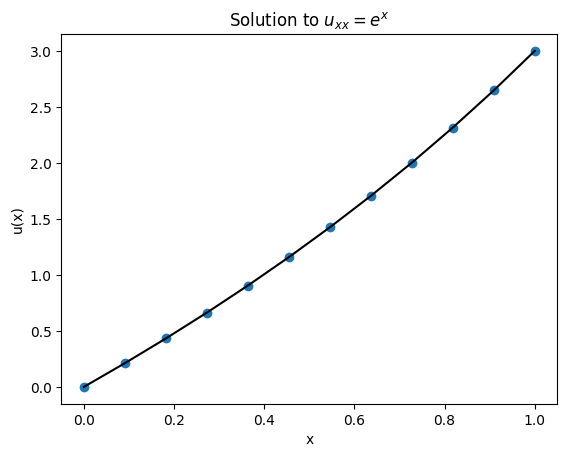

In [3]:

# Problem setup
a = 0.0          # batas kiri domain x
b = 1.0          # batas kanan domain x
u_a = 0.0        # kondisi batas di x = a  -> u(0) = 0
u_b = 3.0        # kondisi batas di x = b  -> u(1) = 3

f = lambda x: numpy.exp(x)  
# fungsi ruas kanan persamaan diferensial u_xx = e^x

u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)
# solusi analitik sebenarnya, digunakan untuk membandingkan hasil numerik


# Discretization
m = 10
# jumlah titik grid di dalam domain (tidak termasuk titik batas)

x_bc = numpy.linspace(a, b, m + 2)
# membuat titik grid dari a sampai b termasuk titik batas

x = x_bc[1:-1]
# mengambil titik interior saja (tanpa titik batas)

delta_x = (b - a) / (m + 1)
# jarak antar grid (Δx)


# Construct matrix A
A = numpy.zeros((m, m))
# membuat matriks kosong ukuran m x m

diagonal = numpy.ones(m) / delta_x**2
# nilai koefisien turunan kedua dari metode beda hingga

A += numpy.diag(diagonal * -2.0, 0)
# mengisi diagonal utama matriks dengan nilai -2/Δx²

A += numpy.diag(diagonal[:-1], 1)
# mengisi diagonal atas dengan 1/Δx²

A += numpy.diag(diagonal[:-1], -1)
# mengisi diagonal bawah dengan 1/Δx²
# hasilnya adalah matriks tridiagonal


# Construct RHS
b = f(x)
# membuat vektor ruas kanan berdasarkan nilai f(x) pada titik grid

b[0] -= u_a / delta_x**2
# memasukkan pengaruh kondisi batas kiri

b[-1] -= u_b / delta_x**2
# memasukkan pengaruh kondisi batas kanan


# Solve system
U = numpy.empty(m + 2)
# membuat vektor solusi termasuk titik batas

U[0] = u_a
# menetapkan nilai solusi di batas kiri

U[-1] = u_b
# menetapkan nilai solusi di batas kanan

U[1:-1] = numpy.linalg.solve(A, b)
# menyelesaikan sistem persamaan linear AU = b
# untuk mendapatkan solusi pada titik interior


# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(x_bc, U, 'o', label="Computed")
# menampilkan solusi numerik (hasil perhitungan)

axes.plot(x_bc, u_true(x_bc), 'k', label="True")
# menampilkan solusi analitik sebenarnya

axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")

plt.show()
# menampilkan grafik hasil

## Analisis Kesalahan

Pertanyaan yang muncul adalah seberapa dekat nilai pendekatan $U_i$ dengan solusi sebenarnya $u(x)$ pada titik grid $x_i$. Untuk itu, kesalahan didefinisikan sebagai

$$
E = U - \widehat{U}
$$

di mana $U$ adalah vektor solusi pendekatan, sedangkan $\widehat{U}$ adalah vektor yang berisi nilai solusi sebenarnya pada titik grid $x_i$, sehingga

$$
\widehat{U_i} = u(x_i)
$$

Karena $E$ merupakan sebuah vektor, kita sering ingin mengetahui bagaimana perilaku kesalahan tersebut terhadap nilai $\Delta x$. Untuk norma $\infty$ diperoleh

$$
||E||_\infty = \max_{1 \leq i \leq m} |E_i| = \max_{1 \leq i \leq m} |U_i - u(x_i)|
$$

Jika dapat ditunjukkan bahwa $||E||_\infty \rightarrow 0$ ketika $\Delta x \rightarrow 0$, maka dapat dikatakan bahwa solusi pendekatan $U_i$ pada titik grid semakin mendekati solusi sebenarnya sehingga $E_i \rightarrow 0$.

Jika menggunakan norma lain, biasanya digunakan bentuk norma yang dimodifikasi dengan melibatkan lebar grid $\Delta x$, yaitu

$$
\begin{aligned}
||E||_1 &= \Delta x \sum_{i=1}^{m} |E_i| \\
||E||_2 &= \left(\Delta x \sum_{i=1}^{m} |E_i|^2 \right)^{1/2}
\end{aligned}
$$

Bentuk ini disebut sebagai norma fungsi grid (grid function norm).

Kesalahan $E$ yang didefinisikan di atas disebut sebagai kesalahan global. Salah satu tujuan utama dalam pembahasan ini adalah memahami bagaimana perilaku $E$ terhadap berbagai faktor yang akan didefinisikan selanjutnya.

### Kesalahan Pemotongan Lokal

Kesalahan pemotongan lokal (Local Truncation Error / LTE) dapat diperoleh dengan mengganti solusi pendekatan $U_i$ dengan solusi sebenarnya $u(x_i)$. Karena persamaan aljabar yang digunakan hanya merupakan pendekatan dari BVP asli, maka solusi sebenarnya tidak akan memenuhi persamaan tersebut secara tepat. Selisih yang muncul dari perbedaan ini disebut sebagai LTE.

Untuk pendekatan beda hingga satu dimensi yang telah diperoleh sebelumnya, persamaannya adalah

$$
\frac{1}{\Delta x^2}(U_{i+1} - 2U_i + U_{i-1}) = f(x_i).
$$

Mengganti $U_i$ dengan $u(x_i)$ pada persamaan tersebut menghasilkan

$$
\tau_i = \frac{1}{\Delta x^2}\left(u(x_{i+1}) - 2u(x_i) + u(x_{i-1})\right) - f(x_i).
$$

Dalam bentuk ini, LTE belum terlalu membantu. Namun jika diasumsikan bahwa $u(x)$ cukup halus (smooth), maka $u(x_{i\pm1})$ dapat dituliskan menggunakan deret Taylor, seperti pada pendekatan beda hingga. Deret Taylor yang digunakan adalah

$$
u(x_{i \pm 1}) =
u(x_i)
\pm u'(x_i)\Delta x
+ \frac{1}{2}u''(x_i)\Delta x^2
\pm \frac{1}{6}u'''(x_i)\Delta x^3
+ \frac{1}{24}u^{(4)}(x_i)\Delta x^4
+ \mathcal{O}(\Delta x^5)
$$

Hal ini menghasilkan bentuk $\tau_i$ sebagai berikut

$$
\begin{aligned}
\tau_i &= \frac{1}{\Delta x^2}\left[u''(x_i)\Delta x^2 + \frac{1}{12}u^{(4)}(x_i)\Delta x^4 + \mathcal{O}(\Delta x^5)\right] - f(x_i) \\
&= u''(x_i) + \frac{1}{12}u^{(4)}(x_i)\Delta x^2 + \mathcal{O}(\Delta x^4) - f(x_i) \\
&= \frac{1}{12}u^{(4)}(x_i)\Delta x^2 + \mathcal{O}(\Delta x^4)
\end{aligned}
$$

di mana solusi sebenarnya memenuhi $u''(x) = f(x)$.

Selama $u^{(4)}(x_i)$ tetap terbatas (halus), maka $\tau_i \rightarrow 0$ ketika $\Delta x \rightarrow 0$.

Kita juga dapat menuliskan vektor LTE sebagai

$$
\tau = A\widehat{U} - F
$$

yang berarti

$$
A\widehat{U} = F + \tau.
$$

Perlu diperhatikan bahwa bentuk ini merupakan hasil evaluasi stensil menggunakan solusi sebenarnya, bukan menggunakan solusi pendekatan.

### Kesalahan Global

Yang ingin dibatasi adalah kesalahan global $E$. Untuk menghubungkan kesalahan global dengan LTE, kita mengganti $E = U - \widehat{U}$ ke dalam persamaan sehingga diperoleh

$$
A E = -\tau.
$$

Hal ini berarti bahwa kesalahan global merupakan solusi dari sistem persamaan yang sama seperti sistem untuk solusi pendekatan, tetapi dengan $\tau$ sebagai fungsi pemaksa, bukan $F$.

Hal ini juga menunjukkan bahwa kesalahan global $E$ dapat dipandang sebagai pendekatan dari BVP yang serupa dengan yang digunakan sebelumnya, yaitu

$$
e''(x) = -\tau(x), \quad \Omega = [0,1]
$$

dengan kondisi batas

$$
e(0) = 0, \quad e(1) = 0.
$$

ODE ini dapat diselesaikan dengan mengintegrasikannya dua kali sehingga diperoleh orde terdepan

$$
\begin{aligned}
e(x) &\approx -\frac{1}{12}\Delta x^2 u''(x) + \frac{1}{12}\Delta x^2 \left(u''(0) + x\left(u''(1) - u''(0)\right)\right) \\
&= \mathcal{O}(\Delta x^2) \rightarrow 0 \quad \text{ketika} \quad \Delta x \rightarrow 0.
\end{aligned}
$$

### Stabilitas

Telah ditunjukkan bahwa analog kontinu dari $E$, yaitu $e(x)$, menuju nol ketika $\Delta x \rightarrow 0$. Namun bagaimana dengan $E$?

Daripada menggunakan hasil dari $e(x)$, kita kembali melihat sistem persamaan untuk kesalahan global

$$
A_{\Delta x} E_{\Delta x} = -\tau_{\Delta x}
$$

di mana notasi ini menunjukkan bentuk sistem untuk jarak grid tertentu $\Delta x$.

Jika matriks $A_{\Delta x}$ dapat dibalik, maka $E_{\Delta x}$ dapat dihitung secara langsung. Dengan asumsi hal tersebut dan menggunakan norma yang sesuai, diperoleh

$$
\begin{aligned}
E_{\Delta x} &= (A_{\Delta x})^{-1}\tau_{\Delta x} \\
||E_{\Delta x}|| &= ||(A_{\Delta x})^{-1}\tau_{\Delta x}|| \\
&\leq ||(A_{\Delta x})^{-1}|| \, ||\tau_{\Delta x}||
\end{aligned}
$$

Telah diketahui bahwa $\tau_{\Delta x} \rightarrow 0$ ketika $\Delta x \rightarrow 0$. Jika norma matriks $(A_{\Delta x})^{-1}$ dapat dibatasi oleh suatu konstanta $C$ untuk $\Delta x$ yang cukup kecil, maka kesalahan global dapat dibatasi oleh

$$
||E_{\Delta x}|| \leq C ||\tau_{\Delta x}||
$$

yang menunjukkan bahwa $E_{\Delta x} \rightarrow 0$ setidaknya secepat $\tau_{\Delta x} \rightarrow 0$.

Pengamatan ini dapat digeneralisasi untuk semua BVP linier dengan mengasumsikan bahwa kita memiliki pendekatan beda hingga untuk BVP linier dalam bentuk

$$
A_{\Delta x} U_{\Delta x} = F_{\Delta x},
$$

di mana $\Delta x$ adalah jarak antar grid.

Pendekatan dikatakan *stabil* jika $(A_{\Delta x})^{-1}$ ada untuk setiap $\Delta x < \Delta x_0$ dan terdapat konstanta $C$ sehingga

$$
||(A_{\Delta x})^{-1}|| \leq C \quad \forall \Delta x < \Delta x_0.
$$

### Konsistensi

Konsep penting dalam diskritisasi PDE adalah bahwa PDE harus konsisten dengan persamaan yang diperkirakan. Jika

$$
||\tau_{\Delta x}|| \rightarrow 0 \quad \text{ketika} \quad \Delta x \rightarrow 0
$$

maka pendekatan tersebut dikatakan *konsisten* dengan persamaan diferensial.

### Konvergensi

Metode dikatakan *konvergen* jika kesalahan global $E$ memenuhi

$$
||E_{\Delta x}|| \rightarrow 0 \quad \text{ketika} \quad \Delta x \rightarrow 0.
$$

Jika suatu pendekatan bersifat konsisten ($||\tau_{\Delta x}|| \rightarrow 0$ ketika $\Delta x \rightarrow 0$) dan stabil ($||E_{\Delta x}|| \leq C ||\tau_{\Delta x}||$), maka pendekatan tersebut bersifat konvergen.

Hasil ini diperoleh untuk kasus BVP linier, tetapi dalam praktiknya kriteria konvergensi ini sering juga berlaku untuk banyak pendekatan beda hingga lainnya. Pernyataan konvergensi ini dapat diperkuat menjadi

$$
\mathcal{O}(\Delta x^p)\ \text{LTE} + \text{stability} \Rightarrow \mathcal{O}(\Delta x^p)\ \text{global error}.
$$

Ternyata bagian yang paling sulit dalam proses ini biasanya adalah membuktikan stabilitas. Pada bagian berikutnya akan ditunjukkan contoh sederhana bagaimana stabilitas dapat dibuktikan menggunakan norma 2.

### Stabilitas dalam 2 Norma

Berdasarkan definisi stabilitas, perlu ditunjukkan bahwa untuk matriks $A$ yang telah didefinisikan sebelumnya berlaku

$$
(A_{\Delta x})^{-1}
$$

ada, dan

$$
||(A_{\Delta x})^{-1}|| \leq C \quad \forall \Delta x < \Delta x_0
$$

untuk suatu konstanta $C$.

Bagaimana kita tahu bahwa $(A_{\Delta x})^{-1}$ ada?

Sekarang diasumsikan bahwa matriks $A$ dapat dibalik, tetapi kita ingin mengetahui apakah norma dari inversnya dapat dibatasi. Perlu diingat bahwa norma-2 dari matriks simetris sama dengan jari-jari spektralnya,

$$
||A||_2 = \rho(A) = \max_{1 \leq p \leq m} |\lambda_p|.
$$

Karena invers dari $A$ juga simetris, maka nilai eigen dari $A^{-1}$ merupakan kebalikan dari nilai eigen $A$. Hal ini berarti

$$
||A^{-1}||_2 = \rho(A^{-1}) = \max_{1 \leq p \leq m} \left|\frac{1}{\lambda_p}\right|
= \frac{1}{\min_{1 \leq p \leq m} |\lambda_p|}.
$$

Jika tidak ada nilai eigen $\lambda_p$ dari $A$ yang bernilai nol untuk $\Delta x$ yang cukup kecil dan nilai lainnya tetap berhingga ketika $\Delta x \rightarrow 0$, maka pendekatan tersebut dapat dikatakan stabil.

Nilai eigen dari matriks $A$ dapat dituliskan sebagai

$$
\lambda_p = \frac{2}{\Delta x^2}\left(\cos(p\pi\Delta x) - 1\right)
$$

dengan vektor eigen yang bersesuaian $v^p$

$$
v^p_j = \sin(p\pi j\Delta x)
$$

sebagai komponen ke-$j$, dengan $j = 1, \ldots, m$.

#### Periksa apakah ini benar merupakan pasangan nilai eigen dan vektor eigen dari matriks $A$

$$
\lambda_p = \frac{2}{\Delta x^2}\left(\cos(p\pi\Delta x) - 1\right)
$$

$$
v^p_j = \sin(p\pi j\Delta x)
$$

$$\begin{aligned}
    (A v^p)_j &= \frac{1}{\Delta x^2} (v^p_{j-1} - 2 v^p_j + v^p_{j+1} ) \\
    &= \frac{1}{\Delta x^2} (\sin(p \pi (j-1) \Delta x) - 2 \sin(p \pi j \Delta x) + \sin(p \pi (j+1) \Delta x) ) \\
    &= \frac{1}{\Delta x^2} (\sin(p \pi j \Delta x) \cos(p \pi \Delta x) - 2 \sin(p \pi j \Delta x) + \sin(p \pi j \Delta x) \cos(p \pi \Delta x) \\
    &= \lambda_p v^p_j.
\end{aligned}$$

#### Hitung nilai eigen terkecil

Jika dapat ditunjukkan bahwa nilai eigen tidak mendekati nol, maka $||A||_2$ akan terbatas. Pada kasus ini nilai eigen bernilai negatif, sehingga perlu ditunjukkan bahwa nilainya selalu kurang dari nol.

$$
\lambda_p = \frac{2}{\Delta x^2}\left(\cos(p\pi\Delta x) - 1\right)
$$

Gunakan deret Taylor dari fungsi cosinus

$$
\cos(p\pi\Delta x) = 1 - \frac{(p\pi\Delta x)^2}{2} + \mathcal{O}(\Delta x^4)
$$

Substitusi ke dalam $\lambda_p$

$$
\begin{aligned}
\lambda_p
&= \frac{2}{\Delta x^2}\left[\left(1 - \frac{(p\pi\Delta x)^2}{2} + \mathcal{O}(\Delta x^4)\right) - 1\right] \\
&= \frac{2}{\Delta x^2}\left[-\frac{(p\pi\Delta x)^2}{2} + \mathcal{O}(\Delta x^4)\right] \\
&= -p^2\pi^2 + \mathcal{O}(\Delta x^2)
\end{aligned}
$$

Sehingga untuk $\Delta x$ kecil diperoleh

$$
\lambda_p \approx -p^2\pi^2 < 0
$$

Dari ekspresi tersebut diperoleh bahwa nilai eigen terkecil adalah

$$
\begin{aligned}
\lambda_1 &= \frac{2}{\Delta x^2}(\cos(p\pi\Delta x) - 1) \\
&= \frac{2}{\Delta x^2}\left(-\frac{1}{2}p^2\pi^2\Delta x^2 + \frac{1}{24}p^4\pi^4\Delta x^4 + \mathcal{O}(\Delta x^6)\right) \\
&= -p^2\pi^2 + \mathcal{O}(\Delta x^2).
\end{aligned}
$$

Nilai eigen ini juga menentukan nilai eigen terbesar dari matriks invers, sehingga diperoleh batas kesalahan

$$
||E^{\Delta x}||_2 \leq ||(A^{\Delta x})^{-1}||_2 \, ||\tau^{\Delta x}||_2
\approx \frac{1}{\pi^2} \, ||\tau^{\Delta x}||_2.
$$

### Stabilitas di $\infty$-Norm

Pendekatan langsung untuk menunjukkan bahwa $||E||_\infty \rightarrow 0$ ketika $\Delta x \rightarrow 0$ adalah dengan menggunakan batas norma matriks

$$
||E||_\infty \leq \frac{1}{\sqrt{\Delta x}} \, ||E||_2.
$$

Sebagai contoh, telah ditunjukkan bahwa $||E||_2 = \mathcal{O}(\Delta x^2)$. Hal ini menunjukkan bahwa

$$
||E||_\infty = \mathcal{O}(\Delta x^{3/2}).
$$

Namun hasil ini kurang memuaskan karena dari diskritisasi kita mengharapkan

$$
||E||_\infty = \mathcal{O}(\Delta x^2).
$$

Untuk mengatasi hal ini, kita kembali pada definisi stabilitas, tetapi kali ini menggunakan norma $\infty$.

Matriks $A$ dapat dipandang sebagai kumpulan pendekatan diskrit untuk *fungsi Green* pada setiap kolom. Konsep ini dapat diterapkan lebih luas, sehingga kita akan meninjau teori fungsi Green dan mengaplikasikannya pada contoh sederhana.

### Green Function

Pertimbangkan BVP dengan kondisi batas Dirichlet

$$
u''(x) = f(x), \quad \Omega = [0, 1]
$$

$$
u(0) = \alpha, \quad u(1) = \beta.
$$

Pilih titik tetap $\bar{x} \in \Omega$. Fungsi Green $G(x;\bar{x})$ adalah solusi dari BVP di atas dengan

$$
f(x) = \delta(x - \bar{x})
$$

dan $\alpha = \beta = 0$. Hal ini dapat dipahami sebagai kasus persamaan panas keadaan tunak dengan sumber panas yang terlokalisasi di dalam domain.

Untuk menemukan fungsi Green pada masalah ini, kita dapat mengintegrasikan di sekitar titik $\bar{x}$ yang berdekatan dengan sumber fungsi $\delta$:

$$
\begin{aligned}
\int_{\bar{x}-\epsilon}^{\bar{x}+\epsilon} u''(x) \, dx &= \int_{\bar{x}-\epsilon}^{\bar{x}+\epsilon} \delta(x - \bar{x}) \, dx \\
u'(\bar{x} + \epsilon) - u'(\bar{x} - \epsilon) &= 1
\end{aligned}
$$

Karena integral dari fungsi $\delta$ pada interval yang mencakup $\bar{x}$ harus 1, maka turunan $u'$ mengalami lompatan sebesar 1 di titik $\bar{x}$.

Setelah beberapa manipulasi aljabar, fungsi Green untuk BVP ini adalah

$$
G(x; \bar{x}) = 
\begin{cases}
(\bar{x} - 1)\, x, & 0 \leq x \leq \bar{x} \\
\bar{x}\,(x - 1), & \bar{x} \leq x \leq 1
\end{cases}.
$$

Salah satu sifat penting dari PDE linier (atau ODE) adalah prinsip superposisi. Hal ini berarti bahwa jika sumber $f(x)$ terdiri dari beberapa fungsi $\delta$, maka solusinya merupakan jumlah dari fungsi Green yang bersesuaian. Misalnya, jika

$$
f(x) = \delta(x - 0.25) + 2 \delta(x - 0.5),
$$

maka solusi adalah

$$
u(x) = G(x; 0.25) + 2\, G(x; 0.5).
$$

Pendekatan ini dapat diperluas ke jumlah tak terbatas dari fungsi $\delta$, sehingga

$$
f(x) = \int_0^1 f(\bar{x}) \, \delta(x - \bar{x}) \, d\bar{x},
$$

dan dengan prinsip superposisi, solusi menjadi

$$
u(x) = \int_0^1 f(\bar{x}) \, G(x; \bar{x}) \, d\bar{x}.
$$

Untuk memasukkan pengaruh kondisi batas, kita dapat menambahkan komponen linier sehingga solusi umum BVP menjadi

$$
u(x) = \alpha (1 - x) + \beta x + \int_0^1 f(\bar{x}) \, G(x; \bar{x}) \, d\bar{x}.
$$

Mengapa semua ini dilakukan? Representasi solusi menggunakan fungsi Green dapat dipandang sebagai operator linier yang bekerja pada fungsi $f(x)$. Dalam istilah operator, kita dapat menulis

$$
\mathcal{A} u = f \quad \Rightarrow \quad u = \mathcal{A}^{-1} f.
$$

Dengan demikian, operator linier $\mathcal{A}$ dapat dianggap sebagai analog kontinu dari matriks diskrit $A$.

Untuk melanjutkan, matriks asli $A$ akan dimodifikasi menjadi versi yang sedikit berbeda berdasarkan diskritisasi yang sama. Alih-alih memindahkan suku batas ke sisi kanan persamaan, kita memperkenalkan dua sel "tidak diketahui" baru, disebut *sel hantu*, yang ditempatkan di tepi grid. Sel-sel ini diberi label $U_0$ dan $U_{m+1}$. Sebenarnya, nilai dari titik-titik ini sudah diketahui karena merupakan kondisi batas.

Sistem yang dimodifikasi dapat dituliskan sebagai

$$
A = \frac{1}{\Delta x^2} 
\begin{bmatrix}
\Delta x^2 & 0  \\
1 & -2 & 1 \\
  & 1 & -2 & 1 \\
  &   & \ddots & \ddots & \ddots \\
  &   &        & 1 & -2 & 1 \\
  &   &        &   & 1 & -2 & 1 \\
  &   &        &   &   & 0 & \Delta x^2
\end{bmatrix}, 
\quad 
U = \begin{bmatrix}
U_0 \\ U_1 \\ \vdots \\ U_m \\ U_{m+1}
\end{bmatrix}, 
\quad 
F = \begin{bmatrix}
\alpha \\ f(x_1) \\ \vdots \\ f(x_m) \\ \beta
\end{bmatrix}.
$$

Keuntungannya adalah kita dapat menerapkan kondisi batas yang lebih umum dan mengisolasi ketergantungan aljabar pada kondisi batas. Kekurangannya adalah matriks tidak lagi berbentuk sederhana seperti sebelumnya.

Sekarang kita beralih ke bentuk matriks $A^{-1}$. Dengan notasi tambahan, misalkan $A_j$ adalah kolom ke-$j$ dan $A_{ij}$ adalah elemen pada baris ke-$i$ dan kolom ke-$j$ dari matriks $A$.

Kita memiliki

$$
A \, A^{-1}_j = e_j,
$$

di mana $e_j$ adalah vektor satuan dengan $1$ pada posisi baris ke-$j$ (kolom ke-$j$ dari matriks identitas).

Perhatikan bahwa sistem ini memiliki kesamaan dengan versi diskritisasi dari masalah fungsi Green. Di sini, $e_j$ mewakili fungsi $\delta$, $A$ adalah operator asli, dan $A^{-1}_j$ menunjukkan efek fungsi $\delta$ ke-$j$ (sesuai $\bar{x}$) pada solusi keseluruhan.

Ternyata matriks invers dapat dituliskan langsung menggunakan fungsi Green (lihat LeVeque untuk detail), sehingga diperoleh

$$
A^{-1}_{ij} = \Delta x \, G(x_i; x_j) = 
\begin{cases}
\Delta x \, (x_j - 1)\, x_i, & i = 1,2,\ldots,j \\
\Delta x \, (x_i - 1)\, x_j, & i = j,j+1,\ldots,m
\end{cases}.
$$

Kita juga dapat menuliskan sisi kanan efektif sistem sebagai

$$
F = \alpha e_0 + \beta e_{m+1} + \sum_{j=1}^m f_j e_j,
$$

dan akhirnya solusi menjadi

$$
U = \alpha A^{-1}_0 + \beta A^{-1}_{m+1} + \sum_{j=1}^m f_j A^{-1}_j,
$$

dengan komponen

$$
U_i = \alpha (1 - x_i) + \beta x_i + \Delta x \sum_{j=1}^m f_j G(x_i; x_j).
$$

Dampak dari semua ini adalah kita sekarang dapat mencoba menghitung norma $\infty$ dari matriks $A^{-1}$. Ingat bahwa norma $\infty$ dari matriks, yang diinduksi dari norma $\infty$ vektor, didefinisikan sebagai

$$
||C||_\infty = \max_{0 \leq i \leq m+1} \sum_{j=0}^{m+1} |C_{ij}|.
$$

Perhatikan bahwa karena bentuk matriks $A^{-1}$, jumlah elemen pada baris pertama adalah

$$
\sum_{j=0}^{m+1} A^{-1}_{0j} = 1,
$$

demikian pula pada baris terakhir,

$$
\sum_{j=0}^{m+1} A^{-1}_{m+1,j} = 1.
$$

Untuk baris lainnya, kita memiliki

$$
A^{-1}_{i,0} < 1 \quad \text{dan} \quad A^{-1}_{i,m+1} < 1.
$$

Baris-baris perantara juga dibatasi sebagai

$$
\sum_{j=0}^{m+1} |A^{-1}_{ij}| \leq 1 + 1 + m \Delta x < 3,
$$

dengan menggunakan fakta bahwa

$$
\Delta x = \frac{1}{m+1}.
$$

Dengan demikian, kita dapat menyimpulkan dengan pasti

$$
||A^{-1}||_\infty < 3 \quad \forall \Delta x.
$$

## Kondisi Batas Neumann

Seperti disebutkan sebelumnya, kita dapat memasukkan jenis kondisi batas lain ke dalam diskritisasi dengan menggunakan versi matriks yang dimodifikasi. Misalkan kita mempertimbangkan masalah awal tetapi dengan salah satu sisi memiliki kondisi batas Neumann:

$$
u''(x) = f(x), \quad \Omega = [-1, 1]
$$

$$
u(-1) = \alpha, \quad u'(1) = \sigma.
$$

**Latihan**

Pertimbangkan BVP:

$$
u''(x) = f(x), \quad \Omega = [-1, 1]
$$

$$
u(-1) = \alpha, \quad u'(1) = \sigma,
$$

dengan solusi eksak

$$
u(x) = -(5 + e) x - (2 + e + e^{-1}) + e^x.
$$

Jelajahi penerapan kondisi batas Neumann dengan:

1. Menggunakan ekspresi orde pertama satu sisi,
2. Menggunakan ekspresi orde kedua di titik tengah, dan
3. Menggunakan ekspresi orde kedua satu sisi.

## Contoh Soal
Diberikan masalah nilai batas (Boundary Value Problem / BVP):

$$
-u''(x) = \sin(\pi x), \quad x \in (0,1)
$$

dengan kondisi batas:

$$
u(0) = 0, \quad u(1) = 0.
$$
Tentukan: 
1. Diskritisasi persamaan menggunakan metode beda hingga pusat orde dua dan tuliskan dalam bentuk:
   $$
   A U = F
   $$

2. Turunkan Local Truncation Error (LTE) dan tentukan ordonya.

3. Tentukan apakah metode tersebut konsisten.

4. Analisis stabilitas dengan melihat sifat matriks $A$.

5. Tentukan orde konvergensi metode.

### Diskritisasi

Gunakan grid:

$$
x_i = i \Delta x, \quad i = 0,1,2,\dots,m+1, \quad \Delta x = \frac{1}{m+1}
$$

Pendekatan beda hingga pusat untuk turunan kedua:

$$
u''(x_i) \approx \frac{U_{i+1} - 2U_i + U_{i-1}}{\Delta x^2}
$$

Substitusi ke persamaan:

$$
-\frac{U_{i+1} - 2U_i + U_{i-1}}{\Delta x^2} = \sin(\pi x_i)
$$

Sehingga diperoleh:

$$
- U_{i-1} + 2U_i - U_{i+1} = \Delta x^2 \sin(\pi x_i)
$$

Bentuk matriks:

$$
A U = F
$$

dengan:

$$
A = \frac{1}{\Delta x^2}
\begin{bmatrix}
2 & -1 & 0 & \cdots \\
-1 & 2 & -1 & \cdots \\
0 & -1 & 2 & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{bmatrix}
$$

### Local Truncation Error (LTE)

Gunakan deret Taylor:

$$
u(x_{i \pm 1}) =
u(x_i) \pm u'(x_i)\Delta x + \frac{1}{2}u''(x_i)\Delta x^2
\pm \frac{1}{6}u'''(x_i)\Delta x^3 + \frac{1}{24}u^{(4)}(x_i)\Delta x^4 + \mathcal{O}(\Delta x^5)
$$

Substitusi ke skema beda hingga:

$$
\tau_i = \frac{1}{\Delta x^2} \left(u(x_{i+1}) - 2u(x_i) + u(x_{i-1})\right) + \sin(\pi x_i)
$$

Hasilnya:

$$
\tau_i = \frac{1}{12} u^{(4)}(x_i) \Delta x^2 + \mathcal{O}(\Delta x^4)
$$

Karena $$u^{(4)}(x)$$ terbatas, maka:

$$
\tau_i = \mathcal{O}(\Delta x^2)
$$

### Konsistensi

Metode dikatakan konsisten jika:

$$
||\tau|| \rightarrow 0 \quad \text{saat} \quad \Delta x \rightarrow 0
$$

Karena:

$$
\tau_i = \mathcal{O}(\Delta x^2)
$$

maka:

$$
||\tau|| \rightarrow 0
$$

Kesimpulan: Metode konsisten orde 2

### Stabilitas

Matriks $$A$$ bersifat:
- Simetris  
- Diagonal dominan  
- Positif definit  

Nilai eigen matriks:

$$
\lambda_p = \frac{2}{\Delta x^2}\left(1 - \cos(p\pi\Delta x)\right)
$$

Karena:

$$
1 - \cos(\theta) \ge 0
$$

maka:

$$
\lambda_p > 0 
$$

Artinya:
- Tidak ada eigenvalue nol  
- $A$ invertible  
- $A^{-1}$ ada  

Selain itu:

$$
||A^{-1}|| \le C
$$

(dapat dibuktikan terbatas)

Kesimpulan: Metode stabil


### Konvergensi

Gunakan hubungan:

$$
||E|| \le ||A^{-1}|| \cdot ||\tau||
$$

Karena:
- $||\tau|| = \mathcal{O}(\Delta x^2)$ 
- $||A^{-1}|| \le C$

maka:

$$
||E|| = \mathcal{O}(\Delta x^2)
$$

Kesimpulan: Metode konvergen orde 2



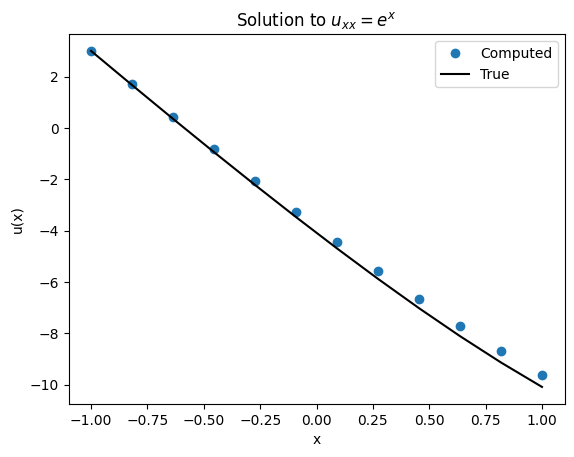

In [4]:
def solve_mixed_1st_order_one_sided(m):
    # Problem setup
    a = -1.0                     # batas kiri domain
    b = 1.0                      # batas kanan domain
    alpha = 3.0                  # nilai kondisi batas Dirichlet di x = a
    sigma = -5.0                 # nilai kondisi batas Neumann di x = b
    f = lambda x: numpy.exp(x)   # fungsi sumber f(x)

    # Descretization
    x_bc = numpy.linspace(a, b, m + 2)  # grid termasuk titik batas
    x = x_bc[1:-1]                       # grid interior
    delta_x = (b - a) / (m + 1)          # jarak antar titik grid

    # Construct matrix A
    A = numpy.zeros((m + 2, m + 2))      # matriks koefisien
    diagonal = numpy.ones(m + 2) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)  # diagonal utama: -2/dx^2
    A += numpy.diag(diagonal[:-1], 1)    # diagonal atas: 1/dx^2
    A += numpy.diag(diagonal[:-1], -1)   # diagonal bawah: 1/dx^2

    # Construct RHS
    b = f(x_bc)                           # vektor sisi kanan awal

    # Boundary conditions
    A[0, 0] = 1.0                         # Dirichlet di x=a
    A[0, 1] = 0.0                         # hilangkan ketergantungan pada U1
    A[-1, -1] = 1.0 / delta_x              # Neumann di x=b
    A[-1, -2] = -1.0 / delta_x             # u'(b) ≈ (U_m+1 - U_m)/dx

    b[0] = alpha                           # nilai kondisi batas Dirichlet
    b[-1] = sigma                          # nilai kondisi batas Neumann

    # Solve system
    U = numpy.linalg.solve(A, b)          # solusi numerik

    return x_bc, U

# Solusi eksak
u_true = lambda x: -(5.0 + numpy.exp(1.0)) * x - (2.0 + numpy.exp(1.0) + numpy.exp(-1.0)) + numpy.exp(x)

# Hitung solusi numerik
x_bc, U = solve_mixed_1st_order_one_sided(10)
    
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")          # solusi numerik
axes.plot(x_bc, u_true(x_bc), 'k', label="True")   # solusi eksak
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
plt.legend()
plt.show()

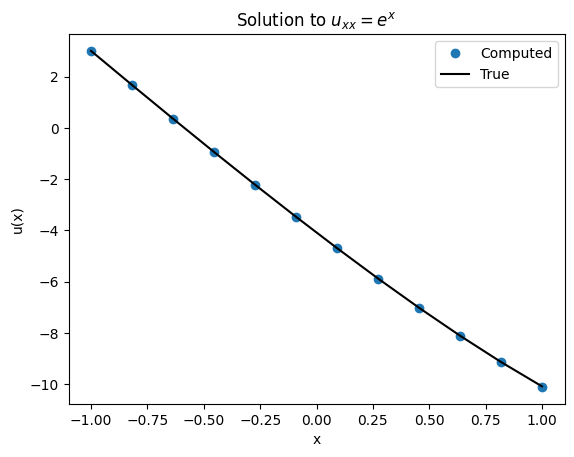

In [5]:
def solve_mixed_2nd_order_centered(m):
    # Problem setup 
    a = -1.0                     # batas kiri domain
    b = 1.0                      # batas kanan domain
    alpha = 3.0                  # nilai kondisi batas Dirichlet di x = a
    sigma = -5.0                 # nilai kondisi batas Neumann di x = b
    f = lambda x: numpy.exp(x)      # fungsi sumber f(x)

    # Descretization 
    x_bc = numpy.linspace(a, b, m + 2)  # grid termasuk titik batas
    x = x_bc[1:-1]                    # grid interior
    delta_x = (b - a) / (m + 1)       # jarak antar titik grid

    #  Construct matrix A 
    A = numpy.zeros((m + 2, m + 2))      # matriks koefisien
    diagonal = numpy.ones(m + 2) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)  # diagonal utama: -2/dx^2
    A += numpy.diag(diagonal[:-1], 1)    # diagonal atas: 1/dx^2
    A += numpy.diag(diagonal[:-1], -1)   # diagonal bawah: 1/dx^2

    # Construct RHS 
    b_vec = f(x_bc)                   # vektor sisi kanan awal

    # Boundary conditions 
    # Dirichlet di x = a
    A[0, 0] = 1.0                      # tetapkan U0 = alpha
    A[0, 1] = 0.0                      # hilangkan ketergantungan pada U1
    b_vec[0] = alpha                   # nilai kondisi batas Dirichlet

    # Neumann di x = b (orde 2, terpusat)
    # u'(b) ≈ (U_{m+1} - U_{m-1}) / (2*dx) = sigma
    A[-1, -1] = -1.0 / delta_x
    A[-1, -2] = 1.0 / delta_x
    b_vec[-1] = delta_x / 2.0 * f(x_bc[-1]) - sigma  # modifikasi RHS untuk orde 2

    # Solve system 
    U = numpy.linalg.solve(A, b_vec)      # solusi numerik

    return x_bc, U

# Hitung solusi numerik 
x_bc, U = solve_mixed_2nd_order_centered(10)

# Plot result 
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")          # solusi numerik
axes.plot(x_bc, u_true(x_bc), 'k', label="True")   # solusi eksak
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
axes.legend()
plt.show()

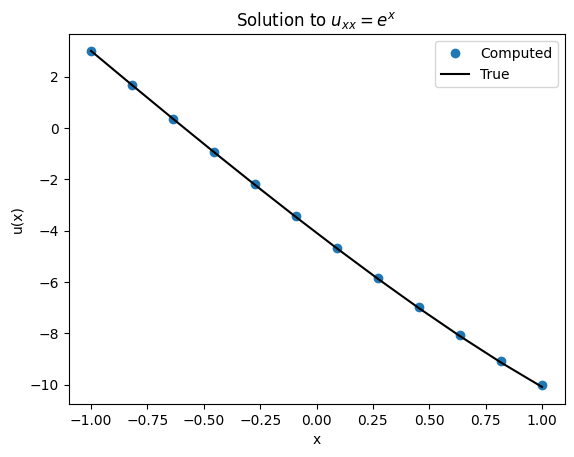

In [6]:
def solve_mixed_2nd_order_one_sided(m):
    # Problem setup
    a = -1.0                     # batas kiri domain
    b = 1.0                      # batas kanan domain
    alpha = 3.0                  # kondisi batas Dirichlet di x = a
    sigma = -5.0                 # kondisi batas Neumann di x = b
    f = lambda x: numpy.exp(x)   # fungsi sumber f(x)
    
    # Descretization
    x_bc = numpy.linspace(a, b, m + 2)  # grid termasuk titik batas
    x = x_bc[1:-1]                      # grid interior
    delta_x = (b - a) / (m + 1)         # jarak antar titik grid
    
    # Construct matrix A
    A = numpy.zeros((m + 2, m + 2))     # matriks koefisien awal
    diagonal = numpy.ones(m + 2) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)     # diagonal utama: -2/dx^2
    A += numpy.diag(diagonal[:-1], 1)       # diagonal atas: 1/dx^2
    A += numpy.diag(diagonal[:-1], -1)      # diagonal bawah: 1/dx^2

    # Construct RHS
    b_vec = f(x_bc)                        # vektor sisi kanan awal

    # Boundary conditions
    # Dirichlet di x = a
    A[0, 0] = 1.0
    A[0, 1] = 0.0
    b_vec[0] = alpha

    # Neumann di x = b (orde 2, one-sided)
    A[-1, -1] = 3.0 / (2.0 * delta_x)
    A[-1, -2] = -4.0 / (2.0 * delta_x)
    A[-1, -3] = 1.0 / (2.0 * delta_x)
    b_vec[-1] = sigma

    # Solve system
    U = numpy.linalg.solve(A, b_vec)        # solusi numerik

    return x_bc, U

# Hitung solusi numerik
x_bc, U = solve_mixed_2nd_order_one_sided(10)

# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")          # solusi numerik
axes.plot(x_bc, u_true(x_bc), 'k', label="True")   # solusi eksak
axes.set_title("Solution to $u_{xx} = e^x$")      # judul sederhana
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
axes.legend()
plt.show()

<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
C:\Users\admin\AppData\Local\Temp\ipykernel_16584\655961810.py:48: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta x$")            # label sumbu x


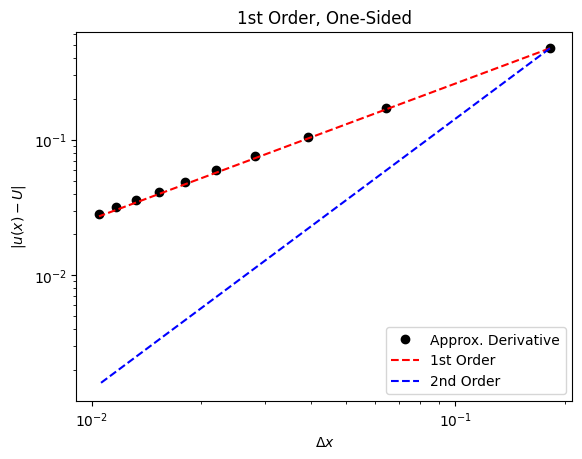

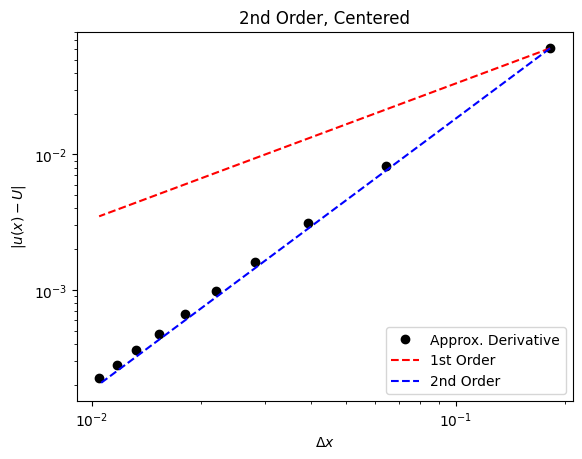

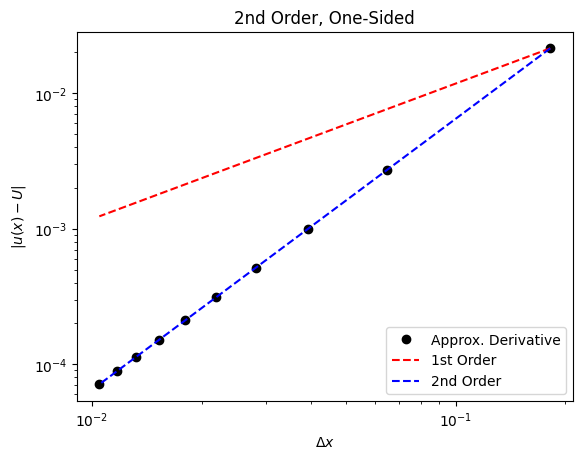

In [7]:
# Problem setup
a = -1.0                              # batas kiri domain
b = 1.0                               # batas kanan domain
alpha = 3.0                            # nilai kondisi batas Dirichlet di x = a
sigma = -5.0                           # nilai kondisi batas Neumann di x = b
f = lambda x: numpy.exp(x)            # fungsi sumber f(x)
u_true = lambda x: -(5.0 + numpy.exp(1.0)) * x - (2.0 + numpy.exp(1.0) + numpy.exp(-1.0)) + numpy.exp(x)  # solusi eksak

# Compute the error as a function of delta_x
m_range = numpy.arange(10, 200, 20)   # jumlah titik grid yang diuji
delta_x = numpy.empty(m_range.shape)  # array untuk menyimpan delta_x
error = numpy.empty((m_range.shape[0], 3))  # array untuk menyimpan error maksimum untuk tiap metode

for (i, m) in enumerate(m_range):
    
    x = numpy.linspace(a, b, m + 2)          # grid termasuk titik batas
    delta_x[i] = (b - a) / (m + 1)          # jarak antar titik grid

    # Hitung solusi tiap metode dan error ∞-norm
    _, U = solve_mixed_1st_order_one_sided(m)     # metode orde 1, one-sided
    error[i, 0] = numpy.linalg.norm(U - u_true(x), ord=numpy.inf)  # simpan error maksimum

    _, U = solve_mixed_2nd_order_one_sided(m)     # metode orde 2, one-sided
    error[i, 1] = numpy.linalg.norm(U - u_true(x), ord=numpy.inf)  # simpan error maksimum

    _, U = solve_mixed_2nd_order_centered(m)      # metode orde 2, centered
    error[i, 2] = numpy.linalg.norm(U - u_true(x), ord=numpy.inf)  # simpan error maksimum

# Judul tiap plot
titles = ["1st Order, One-Sided", "2nd Order, Centered", "2nd Order, One-Sided"]

# Fungsi untuk menghitung garis referensi orde konvergensi
order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))

for i in range(3):
    fig = plt.figure()
    axes = fig.add_subplot(1, 1, 1)

    axes.loglog(delta_x, error[:, i], 'ko', label="Approx. Derivative")   # plot error numerik

    # Garis referensi orde 1
    axes.loglog(delta_x, order_C(delta_x[0], error[0,i], 1.0) * delta_x**1.0, 'r--', label="1st Order")
    # Garis referensi orde 2
    axes.loglog(delta_x, order_C(delta_x[0], error[0,i], 2.0) * delta_x**2.0, 'b--', label="2nd Order")

    axes.legend(loc=4)
    axes.set_title(titles[i])                 # judul plot
    axes.set_xlabel("$\Delta x$")            # label sumbu x
    axes.set_ylabel("$|u(x) - U|$")         # label sumbu y

plt.show()

# Hitung solusi numerik akhir untuk plot perbandingan (opsional)
U = solve_mixed_1st_order_one_sided(10)   # orde 1, one-sided
U = solve_mixed_2nd_order_one_sided(10)   # orde 2, one-sided
U = solve_mixed_2nd_order_centered(10)    # orde 2, centered

#### Keberadaan dan Keunikan

Sebelum menyelesaikan persamaan secara numerik, kita perlu memastikan bahwa persamaan tersebut *diposisikan dengan baik*.  
Masalah dikatakan diposisikan dengan baik jika:  
1. Memiliki **solusi yang unik**.  
2. Solusi **bergantung secara kontinu** pada data masukan, misalnya kondisi awal atau kondisi batas.

#### BVP dengan Kondisi Batas Neumann di Kedua Sisi

Pertimbangkan persamaan batas berikut:
$$
u''(x) = f(x), \quad x \in [0, 1]
$$
dengan kondisi batas Neumann di kedua ujung:
$$
u'(0) = \sigma_0, \quad u'(1) = \sigma_1.
$$

Meskipun kita dapat mendiskritkannya menggunakan metode perbedaan hingga yang sudah dibahas, muncul **masalah terkait keberadaan dan keunikan solusi**.

In [8]:
# Problem setup
a = -1.0                           # batas kiri domain
b = 1.0                            # batas kanan domain
alpha = 3.0                        # kondisi batas Neumann di x = a
sigma = -5.0                        # kondisi batas Neumann di x = b
f = lambda x: numpy.exp(x)         # fungsi sumber f(x)

# Descretization
m = 50                             # jumlah grid interior
x_bc = numpy.linspace(a, b, m + 2) # grid termasuk titik batas
x = x_bc[1:-1]                     # grid interior (tidak termasuk batas)
delta_x = (b - a) / (m + 1)        # jarak antar titik grid

# Construct matrix A
A = numpy.zeros((m + 2, m + 2))    # matriks koefisien awal
diagonal = numpy.ones(m + 2) / delta_x**2
A += numpy.diag(diagonal * -2.0, 0)   # diagonal utama: -2/dx^2
A += numpy.diag(diagonal[:-1], 1)     # diagonal atas: 1/dx^2
A += numpy.diag(diagonal[:-1], -1)    # diagonal bawah: 1/dx^2

# Construct RHS
b = f(x_bc)                        # vektor sisi kanan awal

# Boundary conditions
A[0, 0] = -1.0 / delta_x           # Neumann di x = a, orde 2 (satu sisi)
A[0, 1] = 1.0 / delta_x            # Neumann di x = a, koefisien U1
A[-1, -1] = -1.0 / (delta_x)       # Neumann di x = b, orde 2 (satu sisi)
A[-1, -2] =  1.0 / (delta_x)       # Neumann di x = b, koefisien U_m

b[0] = delta_x / 2.0 * f(x_bc[0]) - alpha   # modifikasi RHS untuk Neumann kiri
b[-1] = delta_x / 2.0 * f(x_bc[-1]) - sigma # modifikasi RHS untuk Neumann kanan

# Solve system
try:
    U = numpy.linalg.solve(A, b)    # menyelesaikan sistem linear
except numpy.linalg.LinAlgError as e: # tangani kesalahan jika matriks singular
    print(e)
    import traceback
    traceback.print_exc()

Singular matrix


Traceback (most recent call last):
  File "C:\Users\admin\AppData\Local\Temp\ipykernel_16584\2909717262.py", line 35, in <module>
    U = numpy.linalg.solve(A, b)    # menyelesaikan sistem linear
  File "c:\Users\admin\.conda\envs\Irfan\Lib\site-packages\numpy\linalg\_linalg.py", line 471, in solve
    r = gufunc(a, b, signature=signature)
  File "c:\Users\admin\.conda\envs\Irfan\Lib\site-packages\numpy\linalg\_linalg.py", line 163, in _raise_linalgerror_singular
    raise LinAlgError("Singular matrix")
numpy.linalg.LinAlgError: Singular matrix


Jika kita melihat matriks A, kita perhatikan bahwa vektor konstanta 
$$
e = [1, 1, 1, 1, 1, \ldots, 1]^T
$$ 
termasuk di ruang nol A. Hal ini menunjukkan bahwa matriks A tidak dapat dibalik (singular) dan masalah BVP dengan kondisi batas hanya pada turunan tidak memiliki solusi unik. Akibatnya, metode numerik menunjukkan bahwa masalah ini tidak terdefinisi dengan baik.

Cara lain untuk memahami masalah ini adalah dengan memikirkan BVP sebagai versi keadaan tunak dari persamaan panas. Jika kita atur 
$$
\sigma_0 = \sigma_1 = 0 \quad \text{dan} \quad f(x) = 0,
$$ 
maka panas tidak bisa keluar dari batang. Solusi keadaan tunak hanya mendistribusikan panas secara merata sepanjang batang, sehingga
$$
u(x) = \int_0^1 u^0(x) \, dx = C,
$$ 
dimana $C$ adalah konstanta.

Masalah ini muncul karena BVP keadaan tunak tidak memiliki informasi tambahan untuk menentukan nilai konstan. Artinya, BVP ini dapat memiliki solusi berupa
$$
u(x) = C
$$
untuk sembarang konstanta $C$.

Jika $f(x) \neq 0$, batang menerima atau kehilangan panas. Dalam kasus ini, solusi mungkin tidak ada sama sekali. Solusi ada hanya jika
$$
\int_0^1 f(x) \, dx = 0,
$$
yang berarti jumlah panas yang masuk dan keluar seimbang. Jika syarat ini terpenuhi, solusi masih tidak unik karena dapat ditambahkan konstanta sembarang.

### Diskritisasi Orde Kedua Linear Umum

Sekarang mari kita jelaskan metode untuk menyelesaikan persamaan tersebut
 $$
    a(x) u''(x) + b(x) u'(x) + c(x) u(x) = f(x) \quad \Omega = [a, b] \\
    u(a) = \alpha \quad u(b) = \beta.
$$

Coba diskritisasikan ini menggunakan perbedaan hingga orde kedua dan tuliskan sistemnya
 $$
    a(x) u''(x) + b(x) u'(x) + c(x) u(x) = f(x) \quad \Omega = [a, b] \\
    u(a) = \alpha \quad u(b) = \beta.
$$

Perkiraan umum selisih hingga orde kedua terhadap persamaan di atas dapat ditulis sebagai
 $$
    a_i \frac{U_{i+1} - 2 U_i + U_{i-1}}{\Delta x^2} + b_i \frac{U_{i+1} - U_{i-1}}{2 \Delta x} + c_i U_i = f_i
$$ 
mengarah ke entri matriks
 $$
    A_{i,i} = -\frac{2 a_i}{\Delta x^2} + c_i
$$ 
pada diagonal dan
 $$
    A_{i,i\pm1} = \frac{a_i}{\Delta x^2} \pm \frac{b_i}{2 \Delta x}
$$ 
pada sub-diagonal.  Kita dapat mengambil kondisi batas dengan menggunakan pendekatan titik hantu atau dengan menggabungkannya ke dalam evaluasi sisi kanan.

### Contoh:

Pertimbangkan masalah konduksi panas keadaan tunak dengan variabel $\kappa(x)$ sehingga
 $$
    (\kappa(x) u'(x))' = f(x), \quad \Omega = [0, 1] \\
    u(0) = \alpha \quad u(1) = \beta
$$

Berdasarkan aturan rantai kita tahu
 $$
    \kappa(x) u''(x) + \kappa'(x) u'(x) = f(x).
$$

Ternyata dalam hal ini pendekatan tersebut sebenarnya bukanlah pendekatan terbaik untuk menyelesaikan masalah.  Dalam banyak kasus, yang terbaik adalah mendiskritisasi bentuk asli fisika daripada formulasi yang mungkin setara.  Untuk mendemonstrasikannya, mari kita coba membangun sistem untuk menyelesaikan persamaan aslinya
 $$
    (\kappa(x) u'(x))' = f(x).
$$

Pertama kita akan memperkirakan ekspresinya
 $$
    \kappa(x) u'(x)
$$ 
tetapi pada titik-titik di tengah-tengah antara titik-titik $x_i$ , yaitu $x_{i + 1/2}$ .

Kami juga akan mengambil perkiraan ini secara efektif menjadi $\Delta x / 2$ dan menemukannya
 $$
    \kappa(x_{i+1/2}) u'(x_{i+1/2}) = \kappa_{i+1/2} \frac{U_{i+1} - U_i}{\Delta x}.
$$

Sekarang mengambil perkiraan ini dan membedakannya dengan perbedaan yang sama yang berpusat di $x_{i-1/2}$ mengarah ke
 $$\begin{aligned}
    (\kappa(x_i) u'(x_i))' &= \frac{1}{\Delta x} \left [ \kappa_{i+1/2} \frac{U_{i+1} - U_i}{\Delta x} - \kappa_{i-1/2} \frac{U_{i} - U_{i-1}}{\Delta x} \right ] \\
    &= \frac{\kappa_{i+1/2}U_{i+1} - \kappa_{i+1/2} U_i -\kappa_{i-1/2} U_{i} + \kappa_{i-1/2} U_{i-1}}{\Delta x^2} \\ 
    &= \frac{\kappa_{i+1/2}U_{i+1} - (\kappa_{i+1/2} + \kappa_{i-1/2}) U_i + \kappa_{i-1/2} U_{i-1}}{\Delta x^2}
\end{aligned}$$

Diskritisasi orde kedua untuk $(\kappa(x) u'(x))'$ menghasilkan entri matriks:

$$
\begin{aligned}
A_{i,i} &= -\frac{\kappa_{i+1/2} + \kappa_{i-1/2}}{\Delta x^2} \\
A_{i,i \pm 1} &= \frac{\kappa_{i\pm 1/2}}{\Delta x^2}
\end{aligned}
$$

Perhatikan bahwa diskritisasi ini **simetris**.

## Persamaan Non-Linear

Sebelumnya kita membahas **persamaan Poisson**, yang merupakan **BVP linier**. Sekarang, mari kita lihat bagaimana mendekati **masalah non-linier**.  

Sebagai contoh, pertimbangkan **pendulum non-linier**:  
- Ada sebuah **massa m** yang dihubungkan ke **batang kaku tak bermassa** dengan panjang L.  
- Batang ini dibiarkan **mengayun** pada satu titik tetap.  
- Sudut ayunan $\theta(t)$ diukur dari posisi setimbang (massa menggantung ke bawah).  

Persamaan gerak pendulum ini nantinya akan **non-linier** karena gaya pemulihannya melibatkan $\sin(\theta)$, bukan hanya $\theta$ seperti pada pendekatan linier.

Sistem pendulum non-linier ini dapat dituliskan sebagai persamaan diferensial:

$$
\theta''(t) = -\,\frac{g}{L} \, \sin(\theta(t))
$$

Untuk menyederhanakan perhitungan, kita **mengambil $\frac{g}{L} = 1$**, sehingga persamaan menjadi:

$$
\theta''(t) = - \sin(\theta(t))
$$

Melihat **deret Taylor** dari $\sin(\theta)$, kita bisa memperkirakan persamaan ini ketika $\theta$ kecil:

$$
\sin(\theta) \approx \theta - \frac{\theta^3}{6} + \mathcal{O}(\theta^5)
$$

Jika kita hanya mengambil **suku pertama**, persamaan non-linier menjadi **linier**:

$$
\theta''(t) = -\theta(t)
$$

Artinya, untuk ayunan kecil, pendulum berperilaku seperti **osilator linier sederhana**.

Persamaan linier untuk pendulum kecil:

$$
\theta''(t) = -\theta(t)
$$

memiliki solusi umum:

$$
\theta(t) = C_1 \cos t + C_2 \sin t
$$

Untuk menentukan **solusi unik**, kita membutuhkan **dua kondisi batas** atau kondisi awal:

1. Posisi awal pendulum: 
$$
\theta(0) = \alpha
$$

2. Bisa juga menentukan posisi pada waktu lain, misal: 
$$
\theta(T) = \beta
$$
atau kecepatan awal:
$$
\theta'(0) = \sigma
$$

- Kondisi ini berbeda dari BVP linier spasial biasa, karena sekarang **domainnya adalah waktu**, bukan ruang.  
- Dua kondisi ini cukup untuk menentukan **konstanta $C_1$ dan $C_2$** dalam solusi umum.

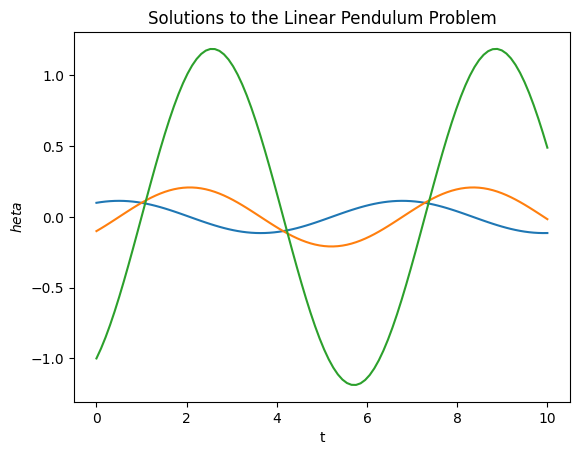

In [9]:
# Simple linear pendulum solutions
def linear_pendulum(t, alpha=0.01, beta=0.01, T=1.0):
    C_1 = alpha                                     # Konstanta dari kondisi awal
    C_2 = (beta - alpha * numpy.cos(T)) / numpy.sin(T)  # Konstanta dari kondisi akhir
    return C_1 * numpy.cos(t) + C_2 * numpy.sin(t)      # Solusi linier pendulum

# Definisi beberapa kondisi awal dan akhir
alpha = [0.1, -0.1, -1.0]   # Posisi awal
beta = [0.1, 0.1, 0.0]      # Posisi akhir
T = [1.0, 1.0, 1.0]         # Waktu total

t = numpy.linspace(0, 10.0, 100)  # Grid waktu untuk plotting

fig = plt.figure()                 # Buat figure baru
axes = fig.add_subplot(1, 1, 1)   # Buat subplot tunggal

# Loop untuk memplot semua solusi untuk kombinasi alpha dan beta
for i in range(len(alpha)):
    axes.plot(t, linear_pendulum(t, alpha[i], beta[i], T[i]))

axes.set_title("Solutions to the Linear Pendulum Problem")  # Judul plot
axes.set_xlabel("t")                                        # Label sumbu x
axes.set_ylabel("$\theta$")                                 # Label sumbu y

plt.show()  # Tampilkan plot

Untuk menangani masalah non-linier sepenuhnya, kita bisa menggunakan diskritisasi beda hingga orde kedua pada turunan waktu.  

Dengan titik waktu diskrit $t_i = i \Delta t$, turunan kedua diaproksimasi sebagai:

$$
\theta''(t_i) \approx \frac{\theta_{i+1} - 2 \theta_i + \theta_{i-1}}{\Delta t^2}
$$

Sehingga persamaan pendulum non-linier menjadi:

$$
\frac{1}{\Delta t^2} (\theta_{i+1} - 2 \theta_i + \theta_{i-1}) + \sin(\theta_i) = 0
$$

Untuk menyelesaikan **BVP non-linier**, metode yang paling umum adalah **metode Newton**.  

Misal kita punya fungsi non-linier $G(\theta)$ dan ingin mencari $\theta$ sehingga:

$$
G(\theta) = 0
$$

Dengan **perluasan Taylor** di sekitar tebakan $\theta^{[k]}$:

$$
G(\theta^{[k+1]}) \approx G(\theta^{[k]}) + G'(\theta^{[k]}) \, (\theta^{[k+1]} - \theta^{[k]})
$$

- Dari sini kita bisa iteratif memperbarui $\theta^{[k+1]}$ hingga konvergen.

Jika kita ingin $G(\theta^{[k+1]}) = 0$, kita bisa menggunakan ekspansi Taylor dan menghilangkan suku tingkat tinggi. Maka diperoleh iterasi Newton:

$$
0 = G(\theta^{[k]}) + G'(\theta^{[k]} \, (\theta^{[k+1]} - \theta^{[k]})
$$

Menyelesaikan untuk $\theta^{[k+1]}$ menghasilkan:

$$
G'(\theta^{[k]} \, \theta^{[k+1]} = G'(\theta^{[k]} \, \theta^{[k]} - G(\theta^{[k]})
$$

Pada titik ini kita perlu berhati-hati: jika sistem persamaan **vektor/matriks**, kita **tidak bisa membagi** dengan $G'(\theta^{[k]})$ secara langsung.  
Sebagai gantinya, kita membalikkan matriks Jacobian atau menyelesaikan sistem linear:

$$
\theta^{[k+1]} = \theta^{[k]} + \delta^{[k]}
$$

dengan

$$
J(\theta^{[k]}) \, \delta^{[k]} = -G(\theta^{[k]})
$$

- Di sini, $J(\theta^{[k]})$ adalah **Jacobian** dari $G$ pada iterasi ke-$k$.  
- $\delta^{[k]}$ adalah **pembaruan** yang digunakan untuk mendapatkan $\theta^{[k+1]}$.

Di sini kita memperkenalkan notasi untuk **matriks Jacobian**, dengan elemen-elemen:

$$
J_{ij}(\theta) = \frac{\partial G_i(\theta)}{\partial \theta_j}
$$

- $J(\theta)$ mengandung semua turunan parsial $G_i$ terhadap semua variabel $\theta_j$.  
- Matriks ini digunakan dalam **iterasi Newton** untuk masalah non-linier.

Untuk sistem non-linier diskrit:

$$
\frac{1}{\Delta t^2} (\theta_{i+1} - 2 \theta_i + \theta_{i-1}) + \sin(\theta_i) = 0
$$

Jacobian $J(\theta)$ dapat ditulis secara umum sebagai:

$$
J_{ij}(\theta) = 
\begin{cases}
\frac{1}{\Delta t^2}, & j = i-1 \text{ atau } j = i+1 \\
-\frac{2}{\Delta t^2} + \cos(\theta_i), & j = i \\
0, & \text{lainnya}
\end{cases}
$$

Dengan **Jacobian** di tangan, kita dapat menyelesaikan BVP non-linier dengan **iterasi Newton** hingga kriteria penghentian terpenuhi, misalnya:

- Perubahan solusi $|\theta^{[k+1]} - \theta^{[k]}|$ cukup kecil  
- Residual $|G(\theta^{[k+1]})|$ mendekati nol  

Proses ini diulang sampai solusi dianggap **cukup akurat**.

### Contoh

Selesaikan masalah **pendulum linier dan non-linier** dengan:

$$
T = 2\pi, \quad \alpha = \beta = 0.7
$$

Pertanyaan:

1. **Persamaan linier:** Apakah memiliki solusi unik?  
2. **Persamaan non-linier:** Apakah kita mengharapkan solusi unik? (Apakah masalah awal non-linier memiliki solusi unik?)

 (1) Step size: 0.2512782262010663
 (2) Step size: 0.0006452832859468563
 (3) Step size: 1.0760234584263571e-08
 (4) Step size: 1.0872594095386544e-14


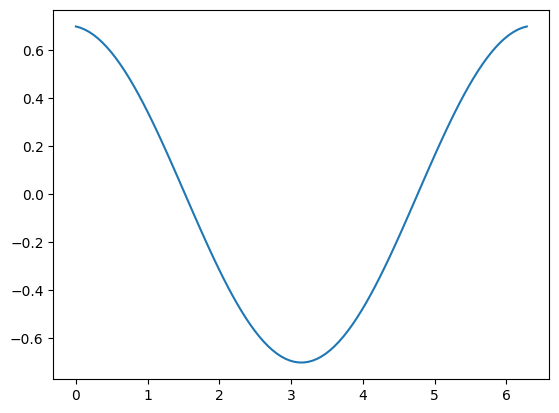

In [10]:
def solve_nonlinear_pendulum(m, alpha, beta, T, max_iterations=100, tolerance=1e-3, verbose=False):
    
    # Discretization
    t_bc = numpy.linspace(0.0, T, m + 2)          # Membuat grid waktu termasuk boundary
    t = t_bc[1:-1]                                # Titik interior
    delta_t = T / (m + 1)                          # Ukuran langkah waktu
    diagonal = numpy.ones(t.shape)                 # Vektor untuk membuat Jacobian tridiagonal
    G = numpy.empty(t_bc.shape)                    # Vektor fungsi non-linier
    
    # Initial guess
    theta = 0.7 * numpy.cos(t_bc)                 # Tebakan awal solusi
    theta[0] = alpha                               # Kondisi awal
    theta[-1] = beta                               # Kondisi akhir
    
    # Main iteration loop
    success = False
    for num_step in range(1, max_iterations):
        
        # Construct Jacobian matrix
        J = numpy.diag(diagonal * -2.0 / delta_t**2 + numpy.cos(theta[1:-1]), 0)  # Diagonal utama
        J += numpy.diag(diagonal[:-1] / delta_t**2, -1)                            # Diagonal bawah
        J += numpy.diag(diagonal[:-1] / delta_t**2, 1)                             # Diagonal atas
        
        # Construct vector G
        G = (theta[:-2] - 2.0 * theta[1:-1] + theta[2:]) / delta_t**2 + numpy.sin(theta[1:-1])
        
        # Take care of BCs
        G[0] = (alpha - 2.0 * theta[1] + theta[2]) / delta_t**2 + numpy.sin(theta[1])   # Persamaan pertama dengan BC
        G[-1] = (theta[-3] - 2.0 * theta[-2] + beta) / delta_t**2 + numpy.sin(theta[-2]) # Persamaan terakhir dengan BC
        
        # Solve
        delta = numpy.linalg.solve(J, -G)      # Hitung pembaruan Newton
        theta[1:-1] += delta                    # Perbarui solusi interior
        
        if verbose:
            print(" (%s) Step size: %s" % (num_step, numpy.linalg.norm(delta)))  # Tampilkan ukuran langkah
        
        if numpy.linalg.norm(delta) < tolerance:  # Periksa konvergensi
            success = True
            break
            
    if not success:
        print(numpy.linalg.norm(delta))
        raise ValueError("Reached maximum allowed steps before convergence criteria met.")  # Peringatan jika gagal konvergen
    
    return t_bc, theta  # Kembalikan grid waktu termasuk BC dan solusi

# Contoh pemanggilan fungsi
t, theta = solve_nonlinear_pendulum(100, 0.7, 0.7, 2.0 * numpy.pi, tolerance=1e-9, verbose=True)
plt.plot(t, theta)  # Plot solusi pendulum non-linier
plt.show()

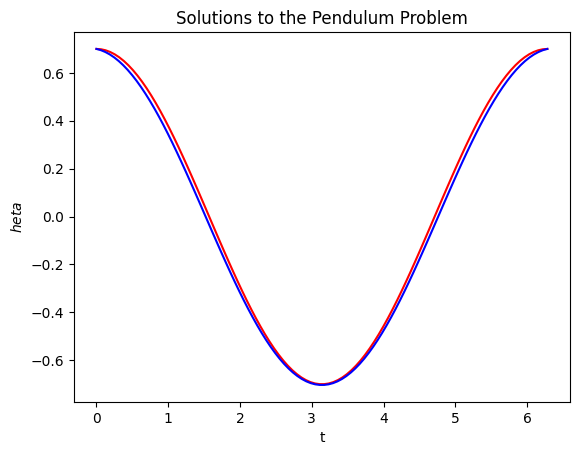

In [11]:
# Linear Problem
alpha = 0.7              # Posisi awal pendulum
beta = 0.7               # Posisi akhir pendulum
T = 2.0 * numpy.pi       # Periode total
t = numpy.linspace(0, T, 100)  # Membuat 100 titik waktu dari 0 sampai T

fig = plt.figure()       # Membuat figure baru
axes = fig.add_subplot(1, 1, 1)  # Membuat subplot tunggal

axes.plot(t, linear_pendulum(t, alpha, beta, T), 'r-', label="Linear")  
# Memplot solusi pendulum linier, garis merah

# Non-linear problem
t, theta = solve_nonlinear_pendulum(100, alpha, beta, T)  
# Menyelesaikan persamaan pendulum non-linier dengan 100 titik, mengembalikan waktu t dan sudut theta

axes.plot(t, theta, 'b-', label="Non-Linear")  
# Memplot solusi pendulum non-linier, garis biru

axes.set_title("Solutions to the Pendulum Problem")  # Judul grafik
axes.set_xlabel("t")                                # Label sumbu x
axes.set_ylabel("$\theta$")                         # Label sumbu y

plt.show()  # Menampilkan grafik

### Akurasi

Saat menyelesaikan masalah non-linier, ada dua sumber kesalahan. Pertama, dari **diskritisasi beda hingga**, yang tergantung pada seberapa besar langkah $\Delta x$; semakin kecil langkah, semakin akurat. Kedua, dari **iterasi Newton**, yang semakin mendekati solusi sebenarnya setiap kali diulang, asalkan asumsi terpenuhi. Kedua hal ini bekerja sama, sehingga kesalahan total dipengaruhi oleh keduanya.

Pertama mari kita hitung LTE
 $$\begin{aligned}
    \tau_{i} &= \frac{1}{\Delta t^2} (\theta(t_{i+1}) - 2 \theta(t_i) + \theta(t_{i-1})) + \sin \theta(t_i) \\
    &= \frac{1}{\Delta t^2} \left (\theta(t_i) + \theta'(t_i) \Delta t + \frac{1}{2} \theta''(t_i) \Delta t^2 + \frac{1}{6} \theta'''(t_i) \Delta t^3 + \frac{1}{24} \theta^{(4)}(t_i) \Delta t^4 - 2 \theta(t_i) \right .\\
    &\quad \quad \quad \left . + \theta(t_i) - \theta'(t_i) \Delta t + \frac{1}{2} \theta''(t_i) \Delta t^2 - \frac{1}{6} \theta'''(t_i) \Delta t^3 + \frac{1}{24} \theta^{(4)}(t_i) \Delta t^4 + \mathcal{O}(\Delta t^5) \right) + \sin \theta(t_i) \\
    &= \frac{1}{\Delta t^2} \left (\theta''(t_i) \Delta t^2 + \frac{1}{12} \theta^{(4)}(t_i) \Delta t^4 \mathcal{O}(\Delta t^6) \right) + \sin \theta(t_i) \\
    &= \theta''(t_i)  + \sin \theta(t_i) + \frac{1}{12} \theta^{(4)}(t_i) \Delta t^2 + \mathcal{O}(\Delta t^4).
\end{aligned}$$

Untuk metode Newton, kita bisa membandingkan solusi perkiraan $\Theta$ dengan solusi sebenarnya $\hat{\Theta}$ dari BVP.  

LTE dapat ditulis sebagai:  
$$
G(\Theta) = 0, \quad G(\hat{\Theta}) = \tau
$$  
sehingga:  
$$
G(\Theta) - G(\hat{\Theta}) = -\tau
$$  

Dengan ekspansi Taylor:  
$$
G(\Theta) \approx G(\hat{\Theta}) + J(\hat{\Theta}) E, \quad E = \Theta - \hat{\Theta}
$$  
maka diperoleh:  
$$
J(\hat{\Theta}) E = -\tau
$$  
yang memberi **ekspresi linier untuk kesalahan global $E$**.  

Metode ini dikatakan **stabil** jika $(J_{\Delta t})^{-1}$ terbatas secara seragam saat $\Delta t \to 0$.  

Jika stabil dan konsisten ($||\tau|| \to 0$), maka:  
$$
||E_{\Delta t}|| \to 0 \quad \text{seiring} \quad \Delta t \to 0
$$  

- Catatan: Newton **hanya konvergen** jika tebakan awal cukup dekat dengan solusi; kesalahan pembulatan tidak selalu membuat metode gagal.